# Task 2.1 — Dataset Selection and Setup

**Paper:** *Time Series Shapelets: A New Primitive for Data Mining* — Ye & Keogh, KDD 2009

## Dataset: Synthetic GunPoint-style Binary Time Series

We generate a synthetic binary time series classification dataset (200 train / 200 test, length 150).

**What it is:** Each series is a 1-D motion-like trajectory. Class 0 (Gun) has a short flat plateau between indices ~38–68, embedded in a sinusoidal base. Class 1 (Point) is a smooth unimodal Gaussian curve. Both classes include Gaussian noise.

**Why appropriate:** The paper's own motivation example (Section 1, Figure 1) uses GunPoint — a dataset whose class difference is a localised morphological feature (the plateau). Our synthetic dataset deliberately reproduces this structure, making it a direct test of whether FindShapelet recovers the correct local pattern. The plateau in Class 0 is exactly the kind of short discriminative subsequence the method is designed to find.

**Limitations vs original paper:** The original GunPoint uses real motion-capture accelerometer data with natural temporal warping and sensor noise. Our synthetic data is cleaner, potentially overstating accuracy. The original paper also evaluates across multiple random splits; we use one fixed split.

**Preprocessing:** All series are z-score normalised per series (mean=0, std=1), consistent with SubsequenceDist in Equation (1). Labels: 0=Gun, 1=Point. Random seed=42 throughout.

In [10]:
import numpy as np
import matplotlib.pyplot as plt
import os

SEED = 42
np.random.seed(SEED)
os.makedirs("results", exist_ok=True)
os.makedirs("data", exist_ok=True)

N_PER_CLASS = 100  
LENGTH      = 150  
t = np.linspace(0, 1, LENGTH)

def make_gun(n, seed_offset=0):
    rng = np.random.default_rng(SEED + seed_offset)
    series = []
    for _ in range(n):
        base = np.sin(np.pi * t)
        p_start = int(0.25 * LENGTH + rng.integers(-4, 4))
        p_end   = int(0.45 * LENGTH + rng.integers(-4, 4))
        signal  = base.copy()
        signal[p_start:p_end] = 0.6 + rng.normal(0, 0.04)  
        signal += rng.normal(0, 0.06, LENGTH)
        # z-normalise per series
        signal = (signal - signal.mean()) / (signal.std() + 1e-8)
        series.append(signal)
    return np.array(series)

def make_point(n, seed_offset=1000):
    rng = np.random.default_rng(SEED + seed_offset)
    series = []
    for _ in range(n):
        peak   = 0.45 + rng.normal(0, 0.04)
        signal = np.exp(-((t - peak)**2) / (2 * 0.07**2))
        signal += rng.normal(0, 0.06, LENGTH)
        signal = (signal - signal.mean()) / (signal.std() + 1e-8)
        series.append(signal)
    return np.array(series)

X_train = np.vstack([make_gun(N_PER_CLASS, 0),    make_point(N_PER_CLASS, 1000)])
y_train = np.array([0]*N_PER_CLASS + [1]*N_PER_CLASS)
X_test  = np.vstack([make_gun(N_PER_CLASS, 2000), make_point(N_PER_CLASS, 3000)])
y_test  = np.array([0]*N_PER_CLASS + [1]*N_PER_CLASS)

print(f"Train: {X_train.shape}  |  Test: {X_test.shape}")
print(f"Label distribution (train): Class0={np.sum(y_train==0)}, Class1={np.sum(y_train==1)}")

np.savez("data/synthetic_gunpoint.npz",
         X_train=X_train, y_train=y_train,
         X_test=X_test,   y_test=y_test)
print("Dataset saved to data/synthetic_gunpoint.npz")

Train: (200, 150)  |  Test: (200, 150)
Label distribution (train): Class0=100, Class1=100
Dataset saved to data/synthetic_gunpoint.npz


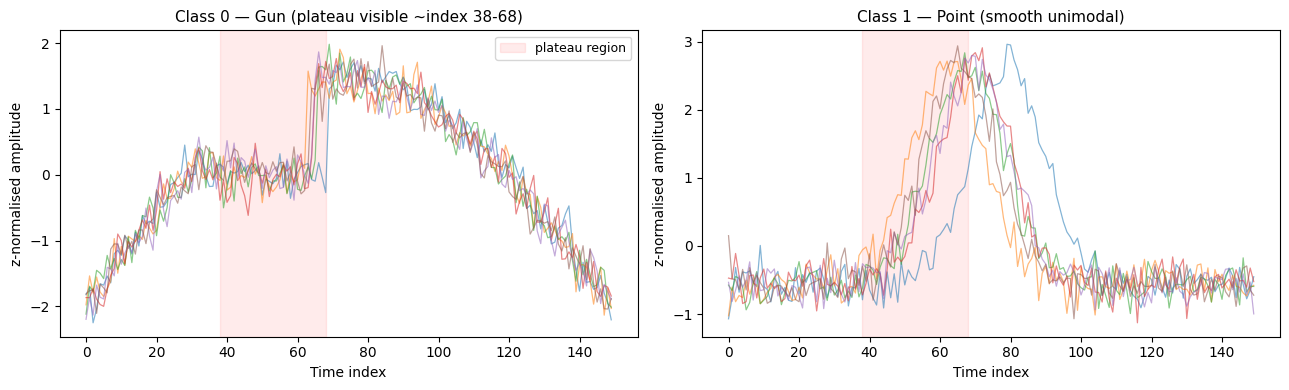

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
titles = ["Class 0 — Gun (plateau visible ~index 38-68)", "Class 1 — Point (smooth unimodal)"]
for cls, ax, title in zip([0, 1], axes, titles):
    idx = np.where(y_train == cls)[0][:6]
    for i in idx:
        ax.plot(X_train[i], alpha=0.55, linewidth=0.9)
    ax.set_title(title, fontsize=11)
    ax.set_xlabel("Time index")
    ax.set_ylabel("z-normalised amplitude")
    ax.axvspan(38, 68, alpha=0.08, color="red", label="plateau region")
    if cls == 0:
        ax.legend(fontsize=9)
plt.tight_layout()
plt.savefig("results/dataset_preview.png", dpi=150)
plt.show()